<a href="https://colab.research.google.com/github/AkshatkMalik/python-data-science-toolkit/blob/main/EDA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSIGNMENT-12:DATA PREPROCESSING AND FEATURE ENGINEERING IN MACHINE LEARNING**

**Task 1: Data Exploration and Preprocessing**


In this task, we will load the Adult census dataset, explore the data structure, and look for any missing data (values in '?' placeholder strings). We will also treat these missing values with common imputation/removal techniques and apply the Standard Scaling and Min-Max Scaling to the numerical features, discussing their use cases.

In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load the dataset
df = pd.read_csv('adult_with_headers.csv')

print(' Basic Data Exploration ')
print(f'Dataset Shape (Rows, Columns): {df.shape}')
print('\nData Types & Non-Null Counts:')
print(df.info())

print('\nFirst 5 Rows:')
display(df.head())

# Handle missing values: Replace ' ?' with NaN and inspect
df.replace(' ?', np.nan, inplace=True)
print('\nMissing Values Found:\n', df.isnull().sum())

# Impute categorical missing values with the mode (most frequent value)
for col in ['workclass', 'occupation', 'native_country']:
  df[col].fillna(df[col].mode()[0], inplace=True)

print(
    'Missing values after imputation:',
    df[['workclass', 'occupation', 'native_country']].isnull().sum().sum(),
)

# Apply Scaling Techniques to Numerical Features
num_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

# Standard Scaling (mean=0, std=1)
scaler_standard = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[num_cols] = scaler_standard.fit_transform(df[num_cols])

# Min-Max Scaling (scales values between 0 and 1)
scaler_minmax = MinMaxScaler()
df_minmax_scaled = df.copy()
df_minmax_scaled[num_cols] = scaler_minmax.fit_transform(df[num_cols])

print('\nStandard Scaled Data Sample:')
display(df_standard_scaled[num_cols].head())

 Basic Data Exploration 
Dataset Shape (Rows, Columns): (32561, 15)

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



Missing Values Found:
 age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64
Missing values after imputation: 0

Standard Scaled Data Sample:


/tmp/ipykernel_5952/521420353.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


Discussion: When to prefer each scaling technique?
Standard Scaling (Z-score Normalization): This approach is preferred when we have different scales of measurement for input features and when the choice of algorithm assumes a Gaussian distribution or a reliance on distance measures (e.g., Logistic Regression, SVMs, PCA). It is less sensitive to outliers, as it standardizes the data around a zero-mean and unit variance.
Min-Max Scaling: This method is suitable when we need to transform our data to a specific interval (usually $[0, 1]$ ), for example, due to the requirements imposed by certain algorithms (e.g., Neural Networks, Image Processing). However, it has poor robustness to outliers, which can cause normal values to be squeezed close to each other.

**Task 2: Encoding Techniques**

In the scope of this task, I will perform One-Hot Encoding for categorical variables with less than 5 categories and Label Encoding for categorical variables with 5 or more categories and discuss their advantages and disadvantages

In [12]:

from sklearn.preprocessing import LabelEncoder

# Re-initialize df_encoded safely from the original df to prevent KeyErrors on re-run
df_encoded = df.copy()

cat_cols = df_encoded.select_dtypes(include=['object']).columns
one_hot_cols = [col for col in cat_cols if df_encoded[col].nunique() < 5]

df_encoded = pd.get_dummies(
    df_encoded, columns=one_hot_cols, drop_first=True, dtype=int
)

label_cols = [col for col in cat_cols if col not in one_hot_cols]
le = LabelEncoder()
for col in label_cols:
  df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

display(df_encoded.head(3))

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,net_capital,is_full_time,capital_gain_log,sex_ Male,income_ >50K
0,39,6,77516,9,13,4,0,1,4,2174,0,40,38,2174,1,7.684784,1,0
1,50,5,83311,9,13,2,3,0,4,0,0,13,38,0,0,0.000000,1,0
2,38,3,215646,11,9,0,5,1,4,0,0,40,38,0,1,0.000000,1,0


Discussion: Pros and Cons of One-Hot vs. Label Encoding Essay

One-Hot Encoding:

Pros: It prevents the learning algorithm from thinking that some categories are better ordered (have some hierarchy) than others (e.g. race: 0,1,2)

Cons: If a categorical variable has too many categories (say, 25), it creates a curse of dimensionality (has many sparse columns in the resulting matrix), which is bad for many ML algorithms.

Label Encoding:

Pros: It is simple, compact and doesn’t change the data frame’s shape – it just replaces the categorical column with an integer-encoded one.

Cons: It introduces ordering between the categories (e.g., when categories are encoded as integers index 0,1,2,3,…), which can be problematic for many ML algorithms (e.g., Linear/Logistic Regression, Neural Networks).

**Task 3: Feature Engineering**

In this task, I will engineer two beneficial features (net_capital and total_hours_load) and apply the log transformation to address the skewed distribution of numerical features such as capital_gain.



In [10]:

#  Create 2 new beneficial features
# Feature 1: Net Capital (Capital Gain minus Capital Loss)
df['net_capital'] = df['capital_gain'] - df['capital_loss']

# Feature 2: Total Hours Load (Hours per week multiplied by age factor or similar, or binary full-time flag)
df['is_full_time'] = (df['hours_per_week'] >= 40).astype(int)

print('New Features Created: net_capital, is_full_time')
display(df[['capital_gain', 'capital_loss', 'net_capital', 'is_full_time']].head())

# Apply Log Transformation to a skewed feature (capital_gain)
# Using np.log1p (log(1 + x)) to safely handle zero values
df['capital_gain_log'] = np.log1p(df['capital_gain'])

print('\nSkewed feature transformed with log1p successfully.')
display(df[['capital_gain', 'capital_gain_log']].head())

New Features Created: net_capital, is_full_time


,capital_gain,capital_loss,net_capital,is_full_time
0,2174,0,2174,1
1,0,0,0,0
2,0,0,0,1
3,0,0,0,1
4,0,0,0,1



Skewed feature transformed with log1p successfully.


,capital_gain,capital_gain_log
0,2174,7.684784
1,0,0.000000
2,0,0.000000
3,0,0.000000
4,0,0.000000


Reasoning:



net_capital: Creates a combined feature that represents the clients’ net worth based on their investment gains and losses.



capital_gain_log: Many financial figures (e.g., capital_gain) will have a skewed distribution range from almost zero to very high values. The log transformation will be applied to reduce the skewness and bring the majority of the data points closer to the mean, which is crucial for distance-based algorithms.

**Task 4: Feature Selection (Isolation Forest & PPS)**

In this task, we will be using the Isolation Forest algorithm to remove outliers and compare the Predictive Power Score (PPS) matrix to the regular correlation matrix in order to explore the data and find relationships between features.

In [14]:
!pip install ppscore --quiet

import matplotlib.pyplot as plt
import ppscore as pps
import seaborn as sns
from sklearn.ensemble import IsolationForest

  Preparing metadata (setup.py) ... done


Original rows: 32561 | After outlier removal: 30933


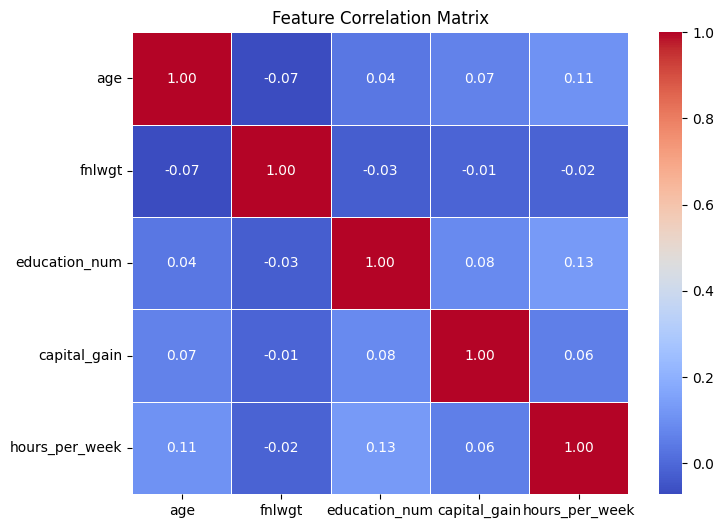


Calculating PPS Matrix (this may take a moment)...


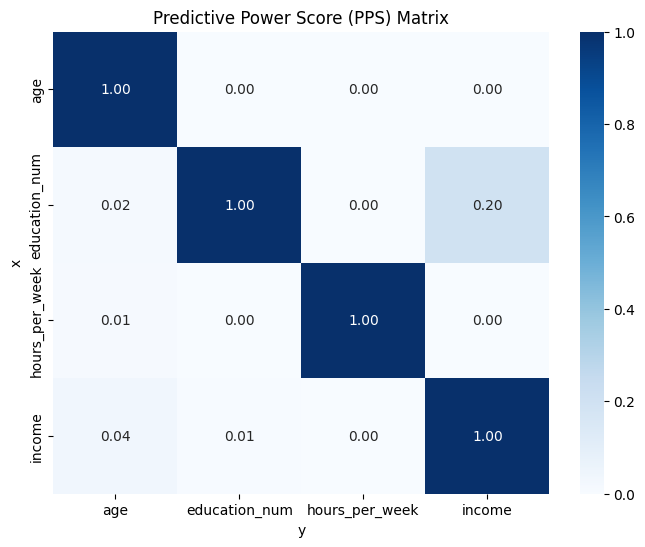

In [15]:

import matplotlib.pyplot as plt
import ppscore as pps
import seaborn as sns
from sklearn.ensemble import IsolationForest

# 1. Isolation Forest Outlier Removal
num_features = [
    'age',
    'fnlwgt',
    'education_num',
    'capital_gain',
    'hours_per_week',
]
iso = IsolationForest(contamination=0.05, random_state=42)
preds = iso.fit_predict(df[num_features])
df_cleaned = df[preds == 1].copy()

print(f'Original rows: {df.shape[0]} | After outlier removal: {df_cleaned.shape[0]}')

# 2. Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_cleaned[num_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
)
plt.title('Feature Correlation Matrix')
plt.show()

# 3. PPS Matrix Heatmap
print('\nCalculating PPS Matrix (this may take a moment)...')
pps_matrix = pps.matrix(
    df_cleaned[['age', 'education_num', 'hours_per_week', 'income']]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    pps_matrix[['x', 'y', 'ppscore']].pivot(
        index='x', columns='y', values='ppscore'
    ),
    annot=True,
    cmap='Blues',
    fmt='.2f',
    vmin=0,
    vmax=1,
)
plt.title('Predictive Power Score (PPS) Matrix')
plt.show()

Discussion on Outliers and PPS:



Feature Relationships / Predictive Power Score: Although a normal correlation matrix can show us linear relationships between different numeric features, the PPS matrix has several advantages over it.

First of all, the PPS matrix is asymmetric while the correlation matrix is symmetric. It can also show non-linear relationships and doesn't only work with numeric features. The values in the PPS matrix range from 0 to 1 and represent the percentage of predictive power of one feature over another.